<a href="https://colab.research.google.com/github/KweonTJ/Machine_Learning/blob/main/10_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11-1. 3차원 공간 데이터에서 주상분 찾기

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
u = np.array([1, 1, 1]) / np.sqrt(3)
v = np.array([1, 0, -1]) / np.sqrt(2)

n_data = 1000
X = []

for _ in range(n_data):
    r_coeff = np.random.randn(2,)
    data = 2.0 * r_coeff[0] * u + r_coeff[1] * v + 0.1 * np.random.rand(3,)
    X.append(data)

X = np.array(X)

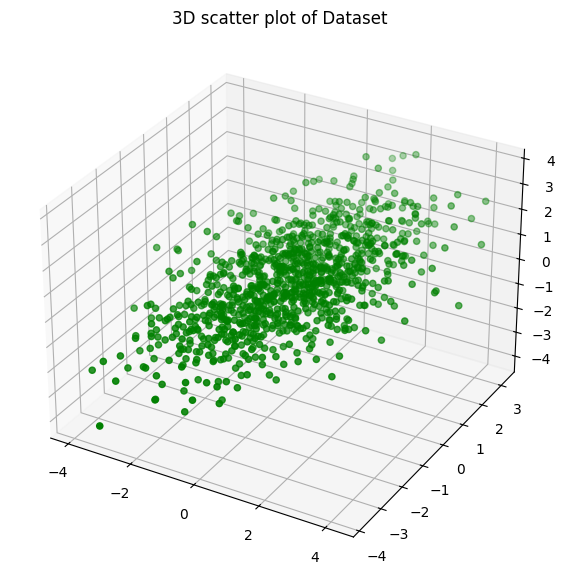

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection="3d")
ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], color="green")
plt.title("3D scatter plot of Dataset")
plt.show()

In [5]:
X_adj = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(X_adj)
Vt.T

array([[ 0.60566686,  0.68324561,  0.4078518 ],
       [ 0.5767582 , -0.0238347 , -0.81656713],
       [ 0.54819488, -0.72979952,  0.4085034 ]])

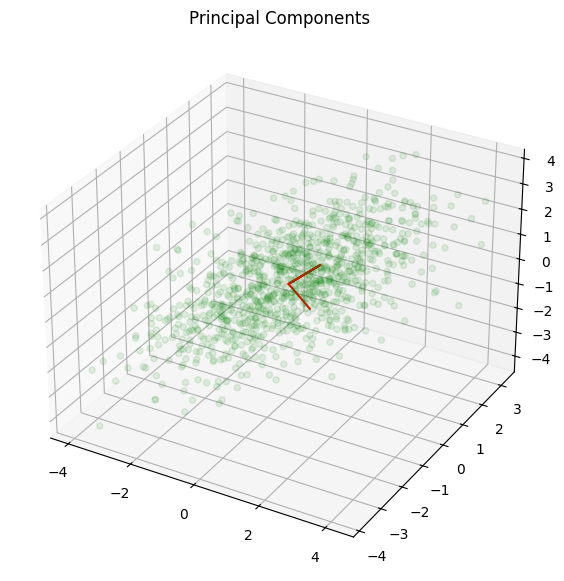

In [7]:
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection="3d")
ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], color="green", alpha=0.1)
plt.title("Principal Components")
origin = np.zeros((1, 3))

C = np.concatenate((origin, Vt[0, :].reshape(-1, 3),
                    origin, Vt[1, :].reshape(-1, 3)), axis=0)

ax.plot3D(C[:, 0], C[:, 1], C[:, 2], color="red")
plt.show()

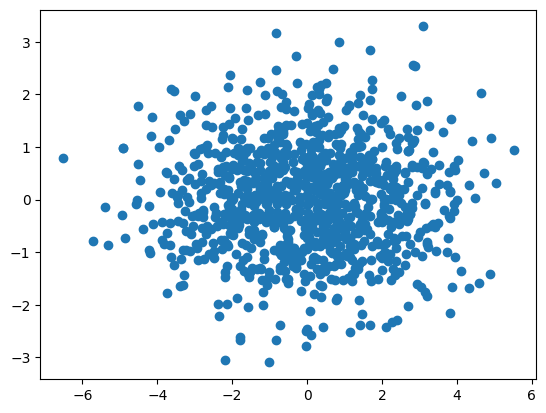

In [8]:
W_2d = Vt.T[:, :2]
X_2d = X_adj.dot(W_2d)

plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.show()

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

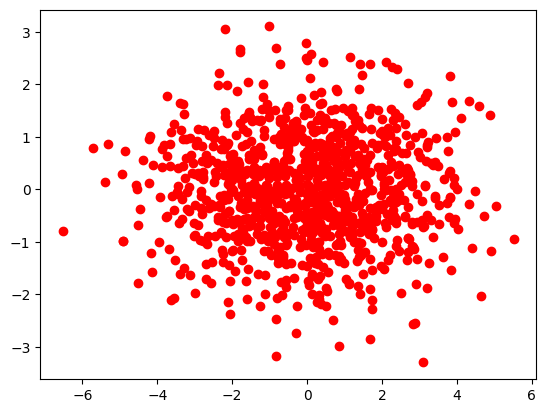

In [10]:
X_2d_sklearn = pca.fit_transform(X)

plt.scatter(X_2d_sklearn[:, 0], X_2d_sklearn[:, 1], color='r')
plt.show()

# 커널 PCA
- 커널 트릭을 사용한 주성분 분석을 할 시엔 사이킷런의 KernelPCA 클래스 사용.
- 커널 트릭을 사용하기에 적합한 데이터 생성 및 선형 PCA와 커널 PCA 비교

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def make_a_roll(num_data):
    f = 3
    unit_length = np.linspace(0, 1, num_data)
    t = f * unit_length * 3.14
    x = np.sin(t) * (unit_length + 0.5) + np.random.randn(num_data) * 0.01
    z = np.cos(t) * unit_length + np.random.randn(num_data) * 0.01
    y = np.random.randn(num_data) * 0.3
    r = unit_length
    g = -(2 * (unit_length - 0.5))**2 + 1
    b = 1 - unit_length
    X = np.array([x, y, z])
    C = np.array([r, g, b])
    return X.T, C.T

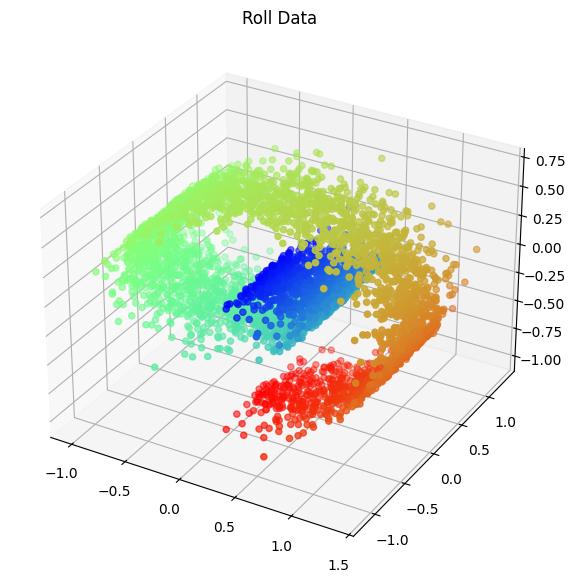

In [12]:
X, color = make_a_roll(5000)

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection="3d")
ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], color=color)
plt.title("Roll Data")
plt.show()

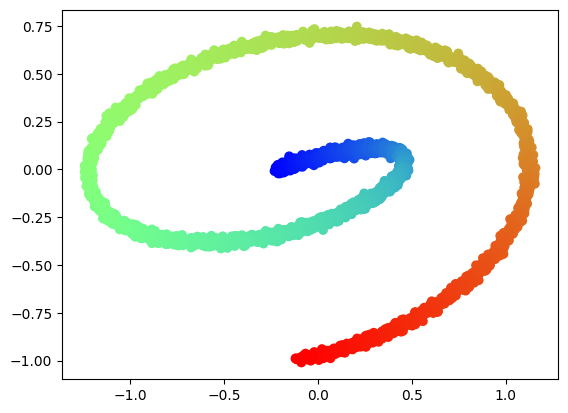

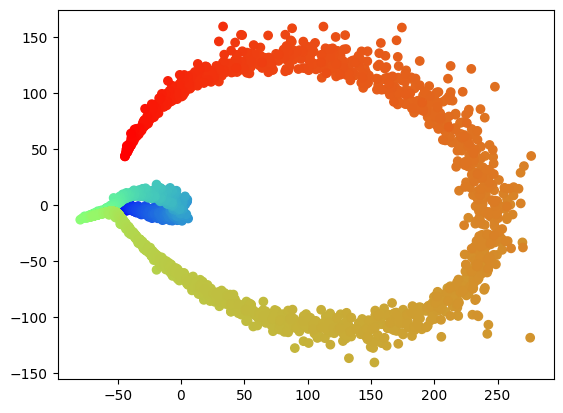

In [26]:
from sklearn.decomposition import PCA, KernelPCA
pca = PCA(n_components=2)
kernel_pca = KernelPCA(n_components=2, kernel='poly',
                        gamma=3.5, degree=5, coef0=3.5)

X_2d = pca.fit_transform(X)
X_2d_kernel = kernel_pca.fit_transform(X)
plt.scatter(X_2d[:, 0], X_2d[:, 1], color=color)
plt.show()
plt.scatter(X_2d_kernel[:, 0], X_2d_kernel[:, 1], color=color)
plt.show()

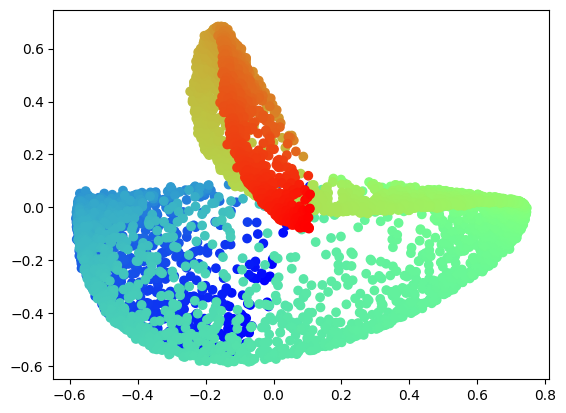

In [27]:
from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components=2, kernel='rbf', gamma=2.2)
X_2d_kernel = kernel_pca.fit_transform(X)
plt.scatter(X_2d_kernel[:, 0], X_2d_kernel[:, 1], color=color)
plt.show()

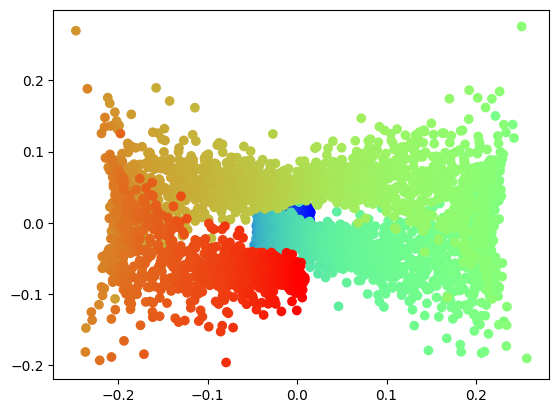

In [28]:
from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components=2, kernel='sigmoid',
                       gamma=1.1, coef0 = 3.0)
X_2d = kernel_pca.fit_transform(X)
plt.scatter(X_2d[:, 0], X_2d[:, 1], color=color)
plt.show()

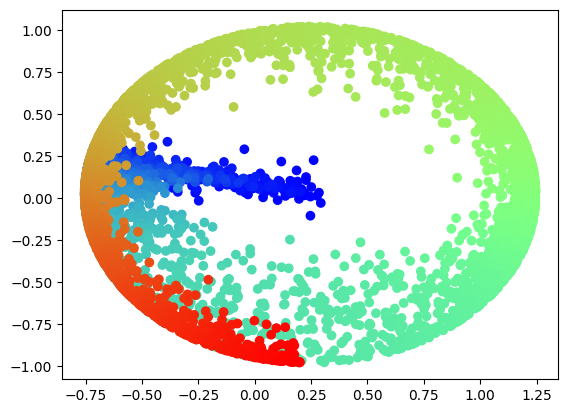

In [29]:
from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components=2, kernel='cosine')
X_2d = kernel_pca.fit_transform(X)
plt.scatter(X_2d[:, 0], X_2d[:, 1], color=color)
plt.show()

#11-2. 주상분을 추출하여 이미지 압축

In [14]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(train_images.shape, test_images.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


In [15]:
def plot_images(nRow, nCol, img, cmap='gray'):
    fig = plt.figure()
    fig, ax = plt.subplots(nRow, nCol, figsize=(nCol, nRow))

    for i in range(nRow):
        for j in range(nCol):
            if nRow <= 1:
                axis = ax[j]
            else:
                axis = ax[i, j]
            axis.get_xaxis().set_visible(False)
            axis.get_yaxis().set_visible(False)
            axis.imshow(img[i*nCol+j], cmap=cmap)

<Figure size 640x480 with 0 Axes>

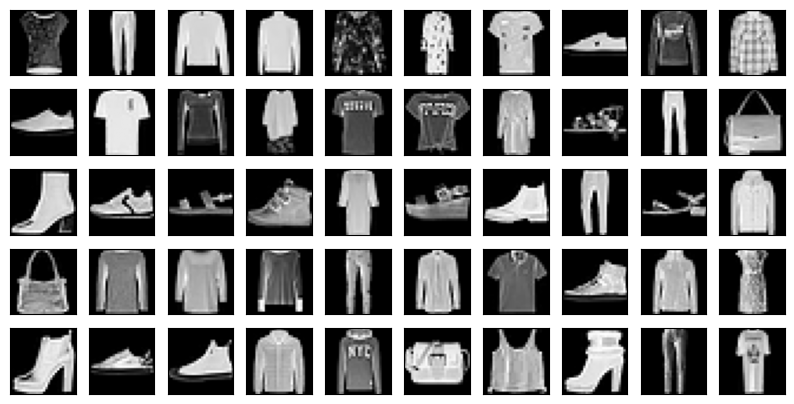

In [16]:
rndinx = np.random.randint(0, len(train_images) - 50)
samples = train_images[rndinx:rndinx+50]
plot_images(5, 10, samples)

In [18]:
from sklearn.decomposition import PCA
train_images_flat = train_images.reshape(-1, 28*28)
pca = PCA(n_components=100)

train_reduced = pca.fit_transform(train_images_flat)

<Figure size 640x480 with 0 Axes>

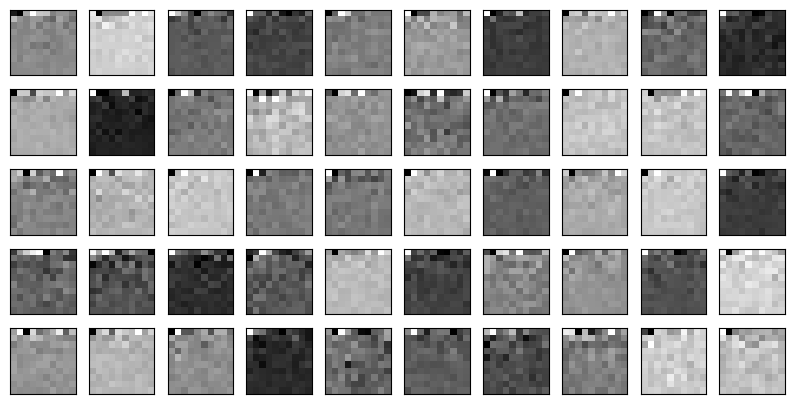

In [19]:
reduced_images = train_reduced.reshape(-1, 10, 10)
plot_images(5, 10, reduced_images[rndinx:rndinx+50])

<Figure size 640x480 with 0 Axes>

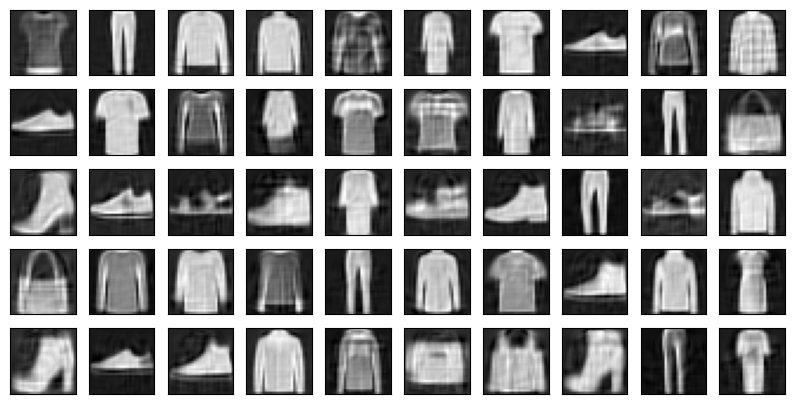

In [20]:
recovered_images = pca.inverse_transform(train_reduced)
recovered_images = recovered_images.reshape(-1, 28, 28)
plot_images(5, 10, recovered_images[rndinx:rndinx+50])

<Figure size 640x480 with 0 Axes>

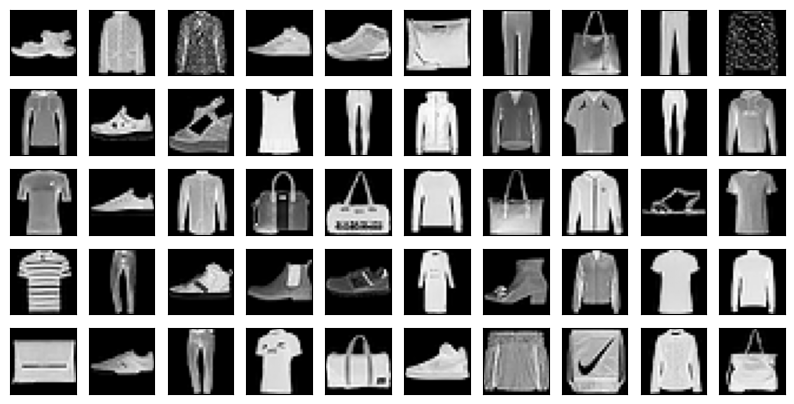

In [21]:
rndinx = np.random.randint(0, len(test_images) - 50)
samples = test_images[rndinx:rndinx+50]
plot_images(5, 10, samples)

<Figure size 640x480 with 0 Axes>

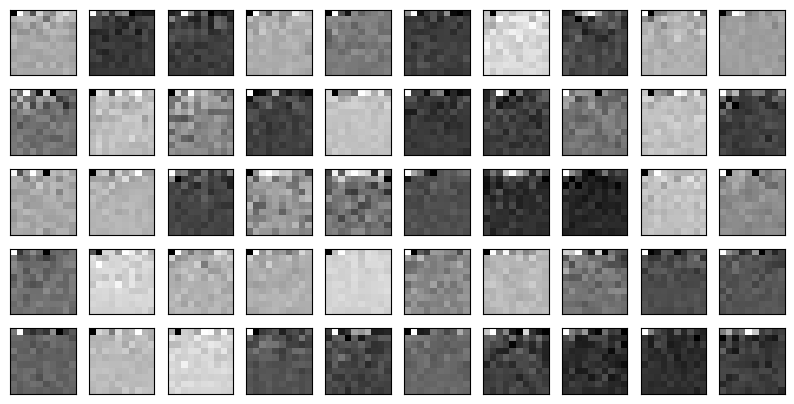

In [23]:
test_images_flat = test_images.reshape(-1, 28*28)
test_reduced = pca.fit_transform(test_images_flat)

reduced_images = test_reduced.reshape(-1, 10, 10)
plot_images(5, 10, reduced_images[rndinx:rndinx+50])

<Figure size 640x480 with 0 Axes>

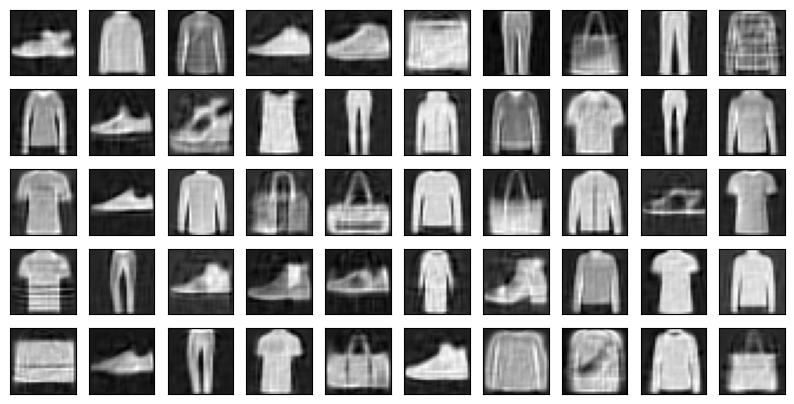

In [24]:
recovered_images = pca.inverse_transform(test_reduced)
recovered_images = recovered_images.reshape(-1, 28, 28)
plot_images(5, 10, recovered_images[rndinx:rndinx+50])

<Figure size 640x480 with 0 Axes>

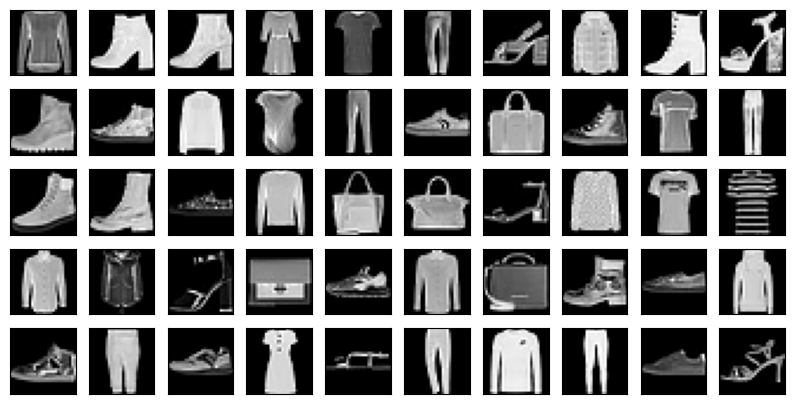

<Figure size 640x480 with 0 Axes>

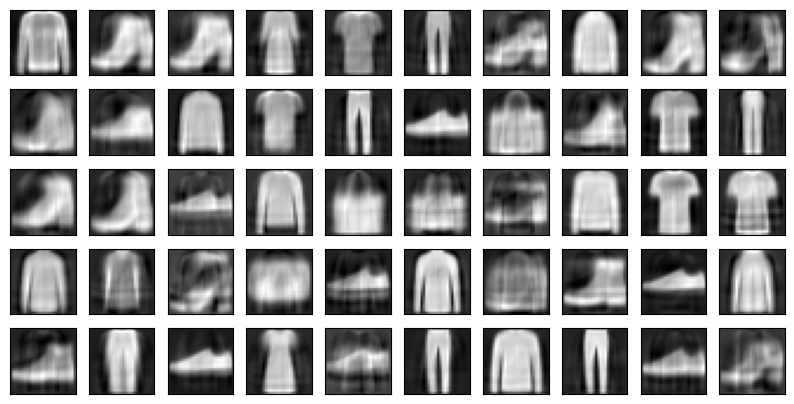

In [25]:
rndinx = np.random.randint(0, len(train_images) - 50)
samples = train_images[rndinx:rndinx+50]
plot_images(5, 10, samples)

train_images_flat = train_images.reshape(-1, 28*28)
pca = PCA(n_components=25)

train_reduced = pca.fit_transform(train_images_flat)
recovered_images = pca.inverse_transform(train_reduced)

recovered_images = recovered_images.reshape(-1, 28, 28)
plot_images(5, 10, recovered_images[rndinx:rndinx+50])